# Heterogeneous Multiscale Methods (HMM) Demonstration

1D elliptic PDE demonstration using FEniCS, implementing the HMM framework and comparing with a high resolution deterministic model and a smooth single scale model.

The governing equation has the form:

$$\frac{d}{dX} \left[ \Gamma \frac{dY}{dX} \right] = F$$

where $\Gamma = g(H, Y, \frac{dY}{dX})$, $F = f(H, Y, \frac{dY}{dX})$ are general functions of a field $H$, the solution $Y$, and the gradient $\frac{dY}{dX}$.


**Three scenarios:**

1. **Smooth macroscale** — Property field $H = H_0(X)$ only (no fine-scale features), solved on a coarse mesh.
2. **Deterministic** — Field $H = H_0(X) + H_1(X, \lambda, \phi)$ now includes fine-scale features or noise, solved on a fine mesh.
3. **HMM coupled multiscale** — Macro-scale solved with homogenised micro solutions providing effective $\bar{\Gamma}$ and $\bar{F}$.

---
**Imports and Setup**

In [37]:
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

import numpy as np
import matplotlib.pyplot as plt
from dolfin import *
set_log_level(LogLevel.WARNING)

---
**Physical Parameters**

Problem dimensions, mesh resolutions, and HMM settings.

In [38]:
LAMBDA = 0.005       # Micro-scale length scale
PHI = 0.0           # Micro-scale phase offset
A_H0 = 0.6          # Amplitude of smooth field H0(X) = A_H0 * sin(2*pi*X)
A_H1 = 0.05        # Amplitude of microscale field H1
F_AMP = 1.0         # Amplitude of source term
L = 1.0             # Macroscale domain length
N_MACRO = 128        # Macro mesh elements (coarse)
N_FINE = 2000       # Fine mesh elements to resolve the microscale features in the deterministic model
N_MICRO = 64        # Micro mesh elements
MAX_HMM_ITER = 50   # Maximum HMM coupling iterations
HMM_TOL = 1e-6      # Convergence tolerance for HMM iteration

---
**Field Definitions**

- $H_0(X) = A_{H_0} \sin(2\pi X)$ — smooth macro
- $H_1(x, \lambda, \phi) = A_{H_1} \sin(2\pi x / \lambda + \phi)$ — fine-scale perturbation

In [39]:
def H0_func(X):
    """Smooth macro field: H0(X) = A_H0 * sin(2*pi*X)"""
    return A_H0 * np.sin(2 * np.pi * X)


def H1_func(x, lam, phi):
    """Fine-scale field perturbation: H1(x, lambda, phi) = A_H1 * sin(2*pi*x/lambda + phi)"""
    return A_H1 * np.sin(2 * np.pi * x / lam + phi)

---
**Constitutive Relations for diffusion and source terms: $\Gamma(H, Y, dY/dX)$ and $F(H, Y, dY/dX)$**

These are the functions used at both macro and micro scales. For this example, $\Gamma$ is dependent on $H$. We could make it fully nonlinear problem by adding $Y$ and $dY/dX$ dependence in both $\Gamma$ and $F$.

In [40]:
def Gamma_func(H, Y=None, dYdX=None):
    """
    Diffusion coefficient as a function of the field.
        Gamma(H, Y, dY/dX) = 1 + H
    """
    return 1.0 + H


def f_source_func(X, H=None, Y=None, dYdX=None):
    """
    Source term:
        f(X) = F_AMP * sin(3*pi*X)
    """
    return F_AMP * np.sin(3 * np.pi * X)

---
**FEniCS Expressions**

Custom classes for evaluating $\Gamma$ and $f$ at quadrature points.

In [41]:
class SmoothGamma(UserExpression):
    """Gamma using only H0: Gamma(H0(X)) = 1 + H0(X)"""
    def eval(self, values, x):
        H0 = H0_func(x[0])
        values[0] = Gamma_func(H0)

    def value_shape(self):
        return ()


class FullGamma(UserExpression):
    """Gamma using full H = H0 + H1: Gamma(H(X)) = 1 + H0(X) + H1(X, lambda, phi)"""
    def eval(self, values, x):
        H = H0_func(x[0]) + H1_func(x[0], LAMBDA, PHI)
        values[0] = Gamma_func(H)

    def value_shape(self):
        return ()


class SourceExpression(UserExpression):
    """Source term: f(X) = F_AMP * sin(3*pi*X)"""
    def eval(self, values, x):
        values[0] = f_source_func(x[0])

    def value_shape(self):
        return ()

---
**Unified FEM Solver**

A single solver function used for all scenarios — only the $\Gamma$ expression and mesh resolution change.

In [42]:
def solve_fem(gamma_expr, n_elements, label="FEM"):
    """
    Solve the 1D elliptic BVP using FEM:

        d/dX [ Gamma * dY/dX ] = f   on [0, L]
        Y(0) = Y(L) = 0

    Same solver for all scenarios — only the Gamma expression and mesh change.
    """
    print(f"  {label}")

    # 1D Mesh with continuous Galerkin elements
    mesh = IntervalMesh(n_elements, 0.0, L)
    V = FunctionSpace(mesh, "CG", 1)

    def boundary(x, on_boundary):
        return on_boundary
    #Fixed dirichlet conditions on the boundaries
    bc = DirichletBC(V, Constant(0.0), boundary)

    u = TrialFunction(V)
    v = TestFunction(V)
    f = SourceExpression(degree=2)

    a_form = gamma_expr * dot(grad(u), grad(v)) * dx
    L_form = f * v * dx

    u_h = Function(V)
    solve(a_form == L_form, u_h, bc)

    coords = mesh.coordinates().flatten()
    idx = np.argsort(coords)
    coords = coords[idx]
    vals = u_h.compute_vertex_values(mesh)[idx]

    print(f"  Mesh elements: {n_elements}")
    print(f"  Solution range: [{vals.min():.6f}, {vals.max():.6f}]")
    print()

    return coords, vals

---
**Scenario 1: Smooth Macroscale Problem**

Field $H = H_0(X)$ only (no micro features). Solved on a coarse macro mesh.

In [43]:
smooth_data = solve_fem(
    SmoothGamma(degree=2), N_MACRO,
    label="Scenario 1: Smooth macro Gamma(H0) on coarse mesh")

  Scenario 1: Smooth macro Gamma(H0) on coarse mesh
  Mesh elements: 128
  Solution range: [-0.013336, 0.019864]



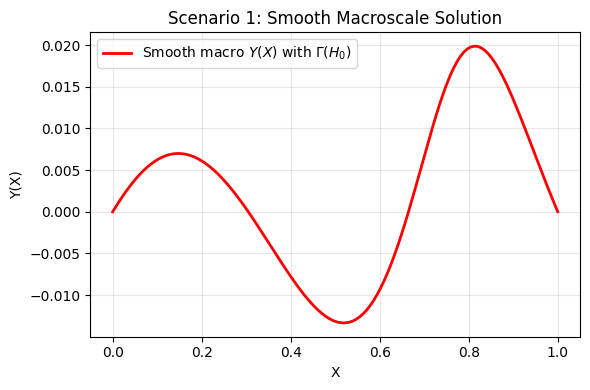

In [44]:
# --- Plot: Smooth macroscale solution ---
coords_s, vals_s = smooth_data

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(coords_s, vals_s, 'r-', linewidth=2, label=r'Smooth macro $Y(X)$ with $\Gamma(H_0)$')
ax.set_xlabel('X')
ax.set_ylabel('Y(X)')
ax.set_title('Scenario 1: Smooth Macroscale Solution')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
**Scenario 2: Deterministic Problem (High resolution)**

Property field $H = H_0(X) + H_1(X, \lambda, \phi)$ with fine-scale texture. Solved on a fine mesh that resolves all oscillations.

In [45]:
fine_data = solve_fem(
    FullGamma(degree=2), N_FINE,
    label="Scenario 2: Fine-resolved FEM with Gamma(H0 + H1)")

  Scenario 2: Fine-resolved FEM with Gamma(H0 + H1)
  Mesh elements: 2000
  Solution range: [-0.013390, 0.019949]



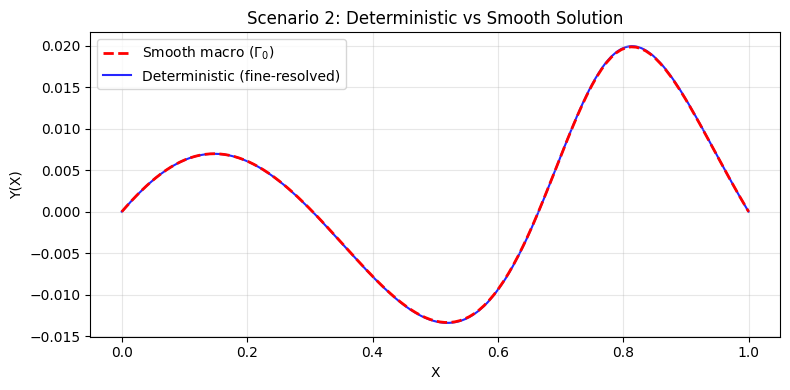

In [46]:
# --- Plot: Deterministic vs Smooth ---
coords_s, vals_s = smooth_data
coords_f, vals_f = fine_data

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(coords_s, vals_s, 'r--', linewidth=2,
        label=r'Smooth macro ($\Gamma_0$)', zorder=2)
ax.plot(coords_f, vals_f, 'b-', alpha=0.85, linewidth=1.5,
        label='Deterministic (fine-resolved)', zorder=1)
ax.set_xlabel('X')
ax.set_ylabel('Y(X)')
ax.set_title('Scenario 2: Deterministic vs Smooth Solution')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
**Scenario 3: HMM**

**Micro/Cell Problem Solver**

Solves the micro problem on a representative microscale cell $[-\lambda/2, \lambda/2]$ for each macro node.

Boundary conditions:
- $y(\lambda/2) = y(-\lambda/2) + \lambda \, dY/dX$ (periodic offset)
- $\Gamma \, dy/dx(-\lambda/2) = \Gamma \, dy/dx(\lambda/2)$ (periodic flux)
- $y(0) = Y$ (centre constraint)

Returns homogenised $\bar{\Gamma}$, $\bar{f}$, and $\bar{H}$ to the macro scale.

In [47]:
def solve_micro_cell_problem(X_macro, Y_macro, dYdX_macro):
    """
    Solve the micro/cell problem on a representative cell.

    Domain: [-lambda/2, lambda/2]

    PDE:    d/dx [ gamma * dy/dx ] = f_micro

    Returns
    -------
    Gamma_bar : float
        Effective Gamma over the cell.
    f_bar : float
        Homogenised source term over the cell.
    H_bar : float
        Homogenised property field over the cell.
    micro_info : dict
        Min/max of y, gamma, f, and h from the micro solution.
    """
    half_lam = LAMBDA / 2.0
    micro_mesh = IntervalMesh(N_MICRO, -half_lam, half_lam)
    V_micro = FunctionSpace(micro_mesh, "CG", 1)

    # Field on the micro domain
    H0_val = H0_func(X_macro)

    class MicroPropertyField(UserExpression):
        """h(x) = H0(X_macro) + H1(x, lambda, phi)"""
        def eval(self, values, x):
            values[0] = H0_val + H1_func(x[0], LAMBDA, PHI)

        def value_shape(self):
            return ()

    h_expr = MicroPropertyField(degree=2)

    class MicroGamma(UserExpression):
        """gamma(x) = Gamma(h(x)) = 1 + h(x)"""
        def eval(self, values, x):
            h = H0_val + H1_func(x[0], LAMBDA, PHI)
            values[0] = Gamma_func(h)

        def value_shape(self):
            return ()

    gamma_micro = MicroGamma(degree=2)

    class MicroSource(UserExpression):
        """f_micro(x) = f(X_macro + x)"""
        def eval(self, values, x):
            values[0] = f_source_func(X_macro + x[0])

        def value_shape(self):
            return ()

    f_micro = MicroSource(degree=2)

    # Boundary conditions with the offset periodicity
    y_left = Y_macro - dYdX_macro * half_lam
    y_right = Y_macro + dYdX_macro * half_lam

    def left_boundary(x, on_boundary):
        return on_boundary and near(x[0], -half_lam)

    def right_boundary(x, on_boundary):
        return on_boundary and near(x[0], half_lam)

    bc_left = DirichletBC(V_micro, Constant(y_left), left_boundary)
    bc_right = DirichletBC(V_micro, Constant(y_right), right_boundary)
    bcs = [bc_left, bc_right]

    # Solve: d/dx [ gamma * dy/dx ] = f_micro
    w = TrialFunction(V_micro)
    v = TestFunction(V_micro)

    a_form = gamma_micro * dot(grad(w), grad(v)) * dx
    L_form = f_micro * v * dx

    y_h = Function(V_micro)
    solve(a_form == L_form, y_h, bcs)

    # --- Homogenisation ---
    gamma_projected = project(gamma_micro, V_micro)
    f_projected = project(f_micro, V_micro)
    h_projected = project(h_expr, V_micro)

    # Gamma_bar: harmonic mean
    inv_gamma = project(Constant(1.0) / gamma_projected, V_micro)
    avg_inv_gamma = assemble(inv_gamma * dx) / LAMBDA
    Gamma_bar = 1.0 / avg_inv_gamma

    # f_bar = (1/lambda) * integral f_micro dx
    f_bar = assemble(f_projected * dx) / LAMBDA

    # H_bar = (1/lambda) * integral h dx
    H_bar = assemble(h_projected * dx) / LAMBDA

    # --- Extract min/max from micro solution for plotting ---
    y_vals = y_h.compute_vertex_values(micro_mesh)
    gamma_vals = gamma_projected.compute_vertex_values(micro_mesh)
    f_vals = f_projected.compute_vertex_values(micro_mesh)
    h_vals = h_projected.compute_vertex_values(micro_mesh)

    micro_coords = micro_mesh.coordinates().flatten()
    micro_sort = np.argsort(micro_coords)
    micro_coords_sorted = micro_coords[micro_sort] + X_macro
    micro_y_sorted = y_vals[micro_sort]

    micro_info = {
        'y_min': y_vals.min(), 'y_max': y_vals.max(),
        'gamma_min': gamma_vals.min(), 'gamma_max': gamma_vals.max(),
        'f_min': f_vals.min(), 'f_max': f_vals.max(),
        'h_min': h_vals.min(), 'h_max': h_vals.max(),
        'micro_coords': micro_coords_sorted,
        'micro_y': micro_y_sorted,
    }

    return Gamma_bar, f_bar, H_bar, micro_info

---
**HMM Coupled Multiscale Solver**

Iterative coupling between macro and micro scales using the **correction formulation**:

$$\frac{d}{dX} \left[ (\Gamma_0 + \Delta\Gamma) \frac{dY}{dX} \right] = (F_0 + \Delta F)$$

where $\Gamma_0 = \Gamma(H_0)$ and $F_0 = F(X)$ are the smooth baseline, and the corrections are:

$$\Delta\Gamma_i = \bar{\Gamma}_i - \Gamma_0(X_i), \qquad \Delta F_i = \bar{F}_i - F_0(X_i)$$

Algorithm:
1. Initial macro solve with smooth $\Gamma_0$, $f_0$ to get $Y$, $dY/dX$.
2. At every macro node, solve a micro cell problem → $\bar{\Gamma}$, $\bar{F}$.
3. Compute corrections: $\Delta\Gamma = \bar{\Gamma} - \Gamma_0$, $\Delta F = \bar{F} - F_0$.
4. Re-solve macro with $(\Gamma_0 + \Delta\Gamma)$ and $(F_0 + \Delta F)$.
5. Iterate until convergence.

In [48]:
def solve_hmm_multiscale():
    """
    HMM coupled multiscale solver using the correction formulation:

        d/dX [ (Gamma_0 + Delta_Gamma) dY/dX ] = (f_0 + Delta_f)

    Micro solves provide Gamma_bar and f_bar; the corrections are:
        Delta_Gamma = Gamma_bar - Gamma_0(X)
        Delta_f     = f_bar     - f_0(X)

    Returns HMM solution, initial smooth solution,
    correction, homogenised quantities, delta arrays, and micro info.
    """
    print("SCENARIO 3: HMM coupled multiscale")

    macro_mesh = IntervalMesh(N_MACRO, 0.0, L)
    V_macro = FunctionSpace(macro_mesh, "CG", 1)

    def boundary(x, on_boundary):
        return on_boundary

    bc = DirichletBC(V_macro, Constant(0.0), boundary)

    u_trial = TrialFunction(V_macro)
    v_test = TestFunction(V_macro)

    # --- Smooth baseline expressions (constant throughout) ---
    gamma_smooth = SmoothGamma(degree=2)
    f_macro_expr = SourceExpression(degree=2)

    # --- Step 1: Initial macro solve with smooth Gamma(H0) ---
    print("  Step 1: Initial macro solve (smooth Gamma_0, f_0)...")

    a_form = gamma_smooth * dot(grad(u_trial), grad(v_test)) * dx
    L_form = f_macro_expr * v_test * dx

    u_macro = Function(V_macro)
    solve(a_form == L_form, u_macro, bc)

    # Store the initial smooth solution for computing correction later
    u_smooth_initial = Function(V_macro)
    u_smooth_initial.vector()[:] = u_macro.vector()[:]

    # Get sorted macro node coordinates and mapping
    macro_coords = macro_mesh.coordinates().flatten()
    sort_idx = np.argsort(macro_coords)
    macro_coords_sorted = macro_coords[sort_idx]
    n_nodes = len(macro_coords_sorted)
    v2d = vertex_to_dof_map(V_macro)

    # Evaluate smooth-scale quantities at macro nodes (fixed reference)
    Gamma0_at_nodes = np.array([Gamma_func(H0_func(x)) for x in macro_coords_sorted])
    f0_at_nodes = np.array([f_source_func(x) for x in macro_coords_sorted])

    # --- Iteration loop ---
    converged_iter = MAX_HMM_ITER
    micro_info_all = None
    Delta_Gamma_nodal = None
    Delta_f_nodal = None

    for hmm_iter in range(MAX_HMM_ITER):
        print(f"\n  --- HMM Iteration {hmm_iter + 1} ---")
        print(f"  Step 2: Solving {n_nodes} micro cell problems...")

        Gamma_bar_nodal = np.zeros(n_nodes)
        f_bar_nodal = np.zeros(n_nodes)
        H_bar_nodal = np.zeros(n_nodes)
        micro_info_list = []

        for i, x_node in enumerate(macro_coords_sorted):
            Y_macro = u_macro(Point(x_node))

            # Compute macro gradient at this node via finite difference
            delta = 0.5 * (L / N_MACRO)
            x_left = max(0.0, x_node - delta)
            x_right = min(L, x_node + delta)
            dYdX_macro = (u_macro(Point(x_right)) - u_macro(Point(x_left))) / \
                         (x_right - x_left)

            Gamma_bar, f_bar, H_bar, micro_info = solve_micro_cell_problem(
                x_node, Y_macro, dYdX_macro)

            Gamma_bar_nodal[i] = Gamma_bar
            f_bar_nodal[i] = f_bar
            H_bar_nodal[i] = H_bar
            micro_info_list.append(micro_info)

            if i % 8 == 0 or i == n_nodes - 1:
                print(f"    Node {i:3d}/{n_nodes-1}: X={x_node:.4f}, "
                      f"Y={Y_macro:+.4f}, dY/dX={dYdX_macro:+.4f}, "
                      f"Gbar={Gamma_bar:.4f}, fbar={f_bar:+.4f}, "
                      f"Hbar={H_bar:+.4f}")

        micro_info_all = micro_info_list

        # --- Step 3: Compute corrections Delta_Gamma, Delta_f ---
        Delta_Gamma_nodal = Gamma_bar_nodal - Gamma0_at_nodes
        Delta_f_nodal = f_bar_nodal - f0_at_nodes

        print("  Step 3: Computing corrections from micro results...")
        print(f"    Delta_Gamma range: [{Delta_Gamma_nodal.min():+.6f}, "
              f"{Delta_Gamma_nodal.max():+.6f}]")
        print(f"    Delta_f     range: [{Delta_f_nodal.min():+.6f}, "
              f"{Delta_f_nodal.max():+.6f}]")

        # Assign corrections to FEniCS Functions
        Delta_Gamma_func = Function(V_macro)
        Delta_f_func = Function(V_macro)

        for i_sorted, i_orig in enumerate(sort_idx):
            dof_idx = v2d[i_orig]
            Delta_Gamma_func.vector()[dof_idx] = Delta_Gamma_nodal[i_sorted]
            Delta_f_func.vector()[dof_idx] = Delta_f_nodal[i_sorted]

        # --- Step 4: Re-solve macro with (Gamma_0 + Delta_Gamma), (f_0 + Delta_f) ---
        print("  Step 4: Macro re-solve with (Gamma_0 + Delta_Gamma) "
              "and (f_0 + Delta_f)...")

        a_form_eff = (gamma_smooth + Delta_Gamma_func) * \
                     dot(grad(u_trial), grad(v_test)) * dx
        L_form_eff = (f_macro_expr + Delta_f_func) * v_test * dx

        u_new = Function(V_macro)
        solve(a_form_eff == L_form_eff, u_new, bc)

        # --- Check convergence ---
        diff = u_new.vector()[:] - u_macro.vector()[:]
        residual = np.sqrt(np.sum(diff**2))
        u_norm = np.sqrt(np.sum(u_macro.vector()[:]**2))
        rel_change = residual / max(u_norm, 1e-14)

        print(f"  Convergence: ||dY|| = {residual:.2e}, "
              f"||dY||/||Y|| = {rel_change:.2e}")

        u_macro.vector()[:] = u_new.vector()[:]

        if rel_change < HMM_TOL:
            converged_iter = hmm_iter + 1
            print(f"  *** Converged after {converged_iter} iteration(s) ***")
            break
    else:
        converged_iter = MAX_HMM_ITER
        print(f"  *** Warning: did not converge in {MAX_HMM_ITER} iterations ***")

    print("\n  Step 5: Computing additive correction...")

    delta_u = Function(V_macro)
    delta_u.vector()[:] = u_macro.vector()[:] - u_smooth_initial.vector()[:]

    coords = macro_coords_sorted
    vals_hmm = u_macro.compute_vertex_values(macro_mesh)[sort_idx]
    vals_smooth = u_smooth_initial.compute_vertex_values(macro_mesh)[sort_idx]
    vals_correction = delta_u.compute_vertex_values(macro_mesh)[sort_idx]

    print(f"  Macro nodes: {n_nodes} (= {N_MACRO} elements + 1)")
    print(f"  Micro solves: {n_nodes} x {converged_iter} iterations = "
          f"{n_nodes * converged_iter} total")
    print(f"  HMM solution range: [{vals_hmm.min():.6f}, {vals_hmm.max():.6f}]")
    print(f"  Max additive correction: {np.max(np.abs(vals_correction)):.6f}")
    print()

    return (coords, vals_hmm, vals_smooth, vals_correction,
            macro_coords_sorted, Gamma_bar_nodal, f_bar_nodal, H_bar_nodal,
            micro_info_all, Delta_Gamma_nodal, Delta_f_nodal,
            Gamma0_at_nodes, f0_at_nodes)

---
**Run HMM Coupled Multiscale Solver**

In [49]:
hmm_data = solve_hmm_multiscale()

SCENARIO 3: HMM coupled multiscale (correction formulation)
  Step 1: Initial macro solve (smooth Gamma_0, f_0)...

  --- HMM Iteration 1 ---
  Step 2: Solving 129 micro cell problems...
    Node   0/128: X=0.0000, Y=+0.0000, dY/dX=+0.0857, Gbar=0.9987, fbar=-0.0000, Hbar=-0.0000
    Node   8/128: X=0.0625, Y=+0.0046, dY/dX=+0.0562, Gbar=1.2286, fbar=+0.5555, Hbar=+0.2296
    Node  16/128: X=0.1250, Y=+0.0068, dY/dX=+0.0151, Gbar=1.4234, fbar=+0.9238, Hbar=+0.4243
    Node  24/128: X=0.1875, Y=+0.0065, dY/dX=-0.0256, Gbar=1.5535, fbar=+0.9807, Hbar=+0.5543
    Node  32/128: X=0.2500, Y=+0.0038, dY/dX=-0.0588, Gbar=1.5992, fbar=+0.7070, Hbar=+0.6000
    Node  40/128: X=0.3125, Y=-0.0006, dY/dX=-0.0792, Gbar=1.5535, fbar=+0.1951, Hbar=+0.5543
    Node  48/128: X=0.3750, Y=-0.0058, dY/dX=-0.0822, Gbar=1.4234, fbar=-0.3826, Hbar=+0.4243
    Node  56/128: X=0.4375, Y=-0.0104, dY/dX=-0.0634, Gbar=1.2286, fbar=-0.8314, Hbar=+0.2296
    Node  64/128: X=0.5000, Y=-0.0132, dY/dX=-0.0190, Gbar=0.

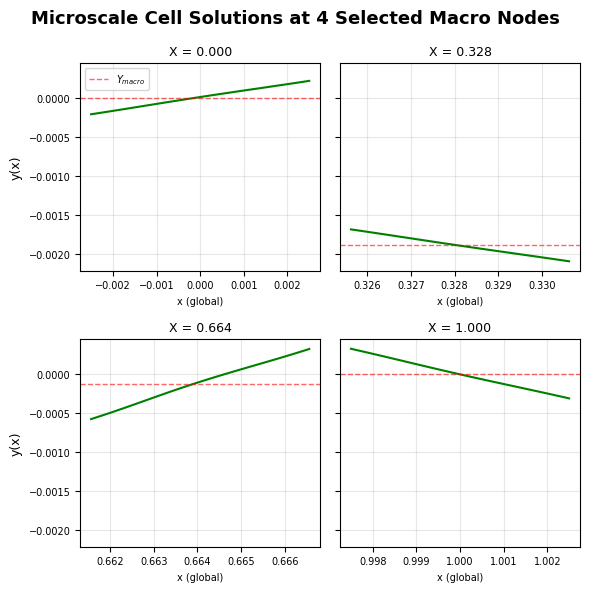

In [57]:
# --- Plot: 10 selected microscale solutions ---
coords_h, vals_hmm, vals_smooth, vals_corr, x_nodes, \
    Gamma_bar, f_bar, H_bar, micro_info_all, \
    Delta_Gamma, Delta_f, Gamma0_nodes, f0_nodes = hmm_data

n_micros = len(micro_info_all)
# Select 10 evenly spaced micro problems to display
selected_indices = np.linspace(0, n_micros - 1, 4, dtype=int)

fig, axes = plt.subplots(2, 2, figsize=(6, 6), sharey=True)
fig.suptitle('Microscale Cell Solutions at 4 Selected Macro Nodes',
             fontsize=13, fontweight='bold')

for ax_idx, mi in enumerate(selected_indices):
    ax = axes.flat[ax_idx]
    info = micro_info_all[mi]
    mc = info['micro_coords']
    my = info['micro_y']
    X_node = x_nodes[mi]

    ax.plot(mc, my, 'g-', linewidth=1.5)
    ax.axhline(y=vals_hmm[mi], color='r', linestyle='--', alpha=0.6,
               linewidth=1, label='$Y_{macro}$' if ax_idx == 0 else None)
    ax.set_title(f'X = {X_node:.3f}', fontsize=9)
    ax.set_xlabel('x (global)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

axes[0, 0].set_ylabel('y(x)', fontsize=9)
axes[1, 0].set_ylabel('y(x)', fontsize=9)
axes[0, 0].legend(fontsize=7, loc='best')
plt.tight_layout()
plt.show()

---
**Error Summary**

Comparison of HMM solution against the high-resolution deterministic reference.

In [51]:
coords_h, vals_hmm, vals_smooth, vals_corr, x_nodes, \
    Gamma_bar, f_bar, H_bar, micro_info_all, \
    Delta_Gamma, Delta_f, Gamma0_nodes, f0_nodes = hmm_data
coords_f, vals_f = fine_data

print("ERROR SUMMARY")

fine_on_macro = np.interp(coords_h, coords_f, vals_f)
l2_err_hmm = np.sqrt(np.mean((vals_hmm - fine_on_macro)**2))
linf_err_hmm = np.max(np.abs(vals_hmm - fine_on_macro))

print(f"  HMM vs fine-resolved FEM:")
print(f"    L2 error:   {l2_err_hmm:.6e}")
print(f"    Linf error: {linf_err_hmm:.6e}")


ERROR SUMMARY
  HMM vs fine-resolved FEM:
    L2 error:   5.364560e-06
    Linf error: 1.782592e-05


---
**Plotting**

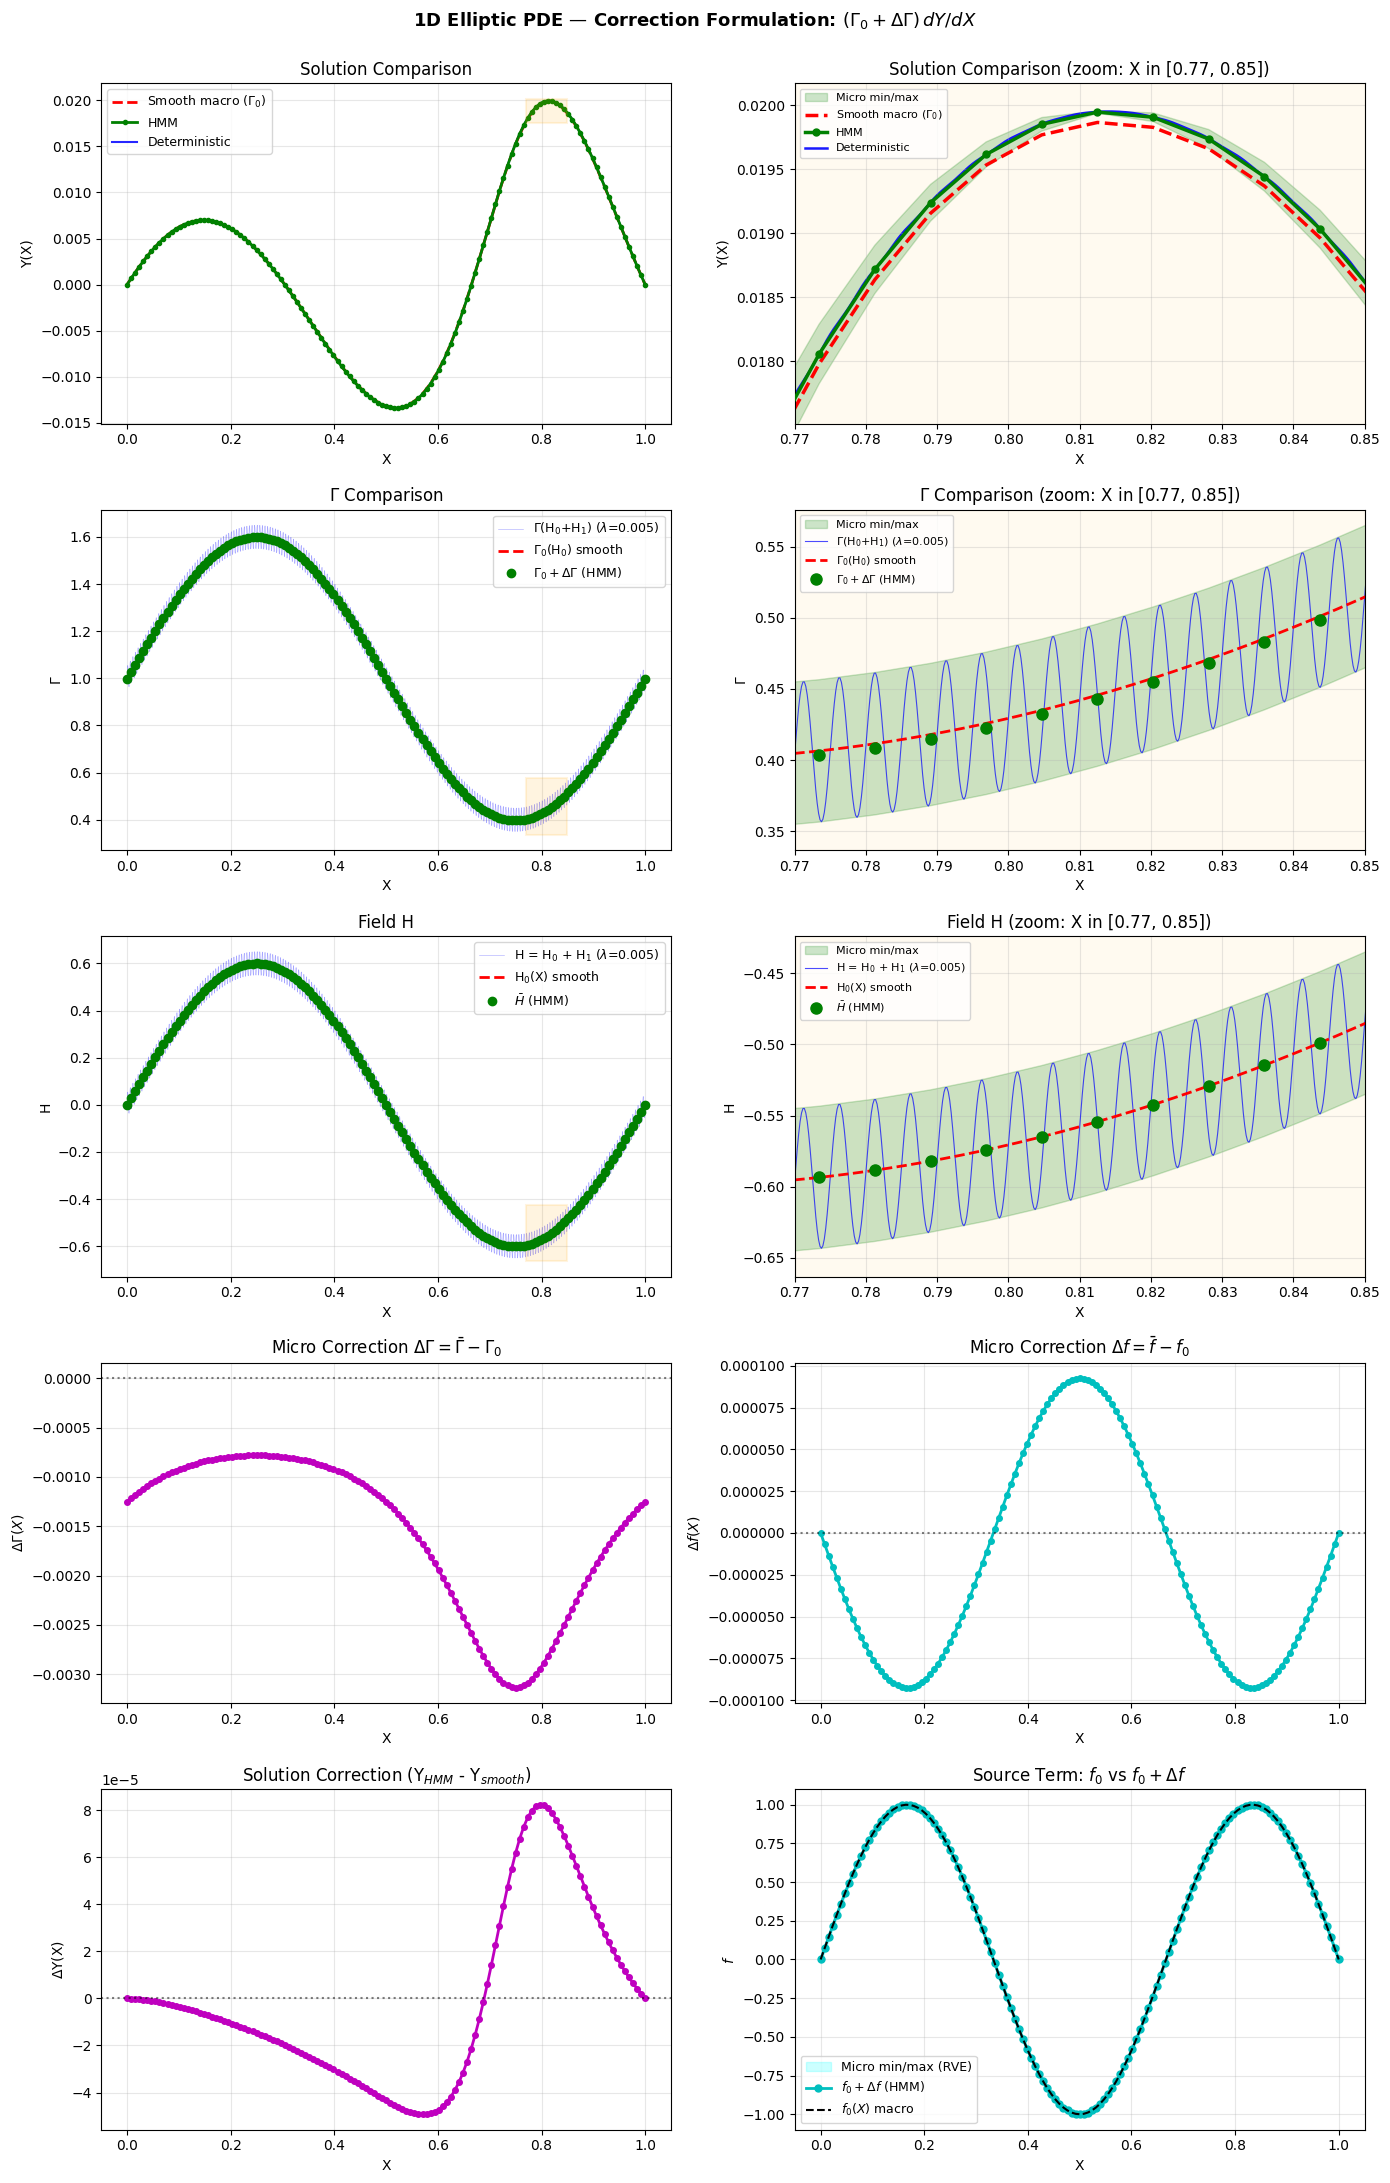

In [52]:
from matplotlib.patches import Rectangle

coords_s, vals_s = smooth_data

# Extract micro min/max arrays
y_micro_min = np.array([m['y_min'] for m in micro_info_all])
y_micro_max = np.array([m['y_max'] for m in micro_info_all])
gamma_micro_min = np.array([m['gamma_min'] for m in micro_info_all])
gamma_micro_max = np.array([m['gamma_max'] for m in micro_info_all])
f_micro_min = np.array([m['f_min'] for m in micro_info_all])
f_micro_max = np.array([m['f_max'] for m in micro_info_all])
h_micro_min = np.array([m['h_min'] for m in micro_info_all])
h_micro_max = np.array([m['h_max'] for m in micro_info_all])

# --- Zoom region ---
ZOOM_LEFT = 0.77
ZOOM_RIGHT = 0.85

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
fig.suptitle("1D Elliptic PDE — Correction Formulation: "
             r"$(\Gamma_0 + \Delta\Gamma)\,dY/dX$" "\n",
             fontsize=13, fontweight='bold', y=0.99)

# ================================================================
# Panel 1: Solutions comparison
# ================================================================
ax = axes[0, 0]
ax.plot(coords_s, vals_s, 'r--', linewidth=2,
        label=r'Smooth macro ($\Gamma_0$)', zorder=2)
ax.plot(coords_h, vals_hmm, 'g-o', linewidth=2, markersize=3,
        label='HMM', zorder=3)
ax.plot(coords_f, vals_f, 'b-', alpha=0.85, linewidth=1.5,
        label='Deterministic', zorder=1)
ax.set_xlabel('X')
ax.set_ylabel('Y(X)')
ax.set_title('Solution Comparison')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Draw zoom rectangle
zoom_mask_f = (coords_f >= ZOOM_LEFT) & (coords_f <= ZOOM_RIGHT)
zoom_mask_h = (coords_h >= ZOOM_LEFT) & (coords_h <= ZOOM_RIGHT)
zoom_mask_s = (coords_s >= ZOOM_LEFT) & (coords_s <= ZOOM_RIGHT)
y_vals_in_zoom = np.concatenate([
    vals_f[zoom_mask_f], vals_hmm[zoom_mask_h], vals_s[zoom_mask_s]
])
y_lo = y_vals_in_zoom.min()
y_hi = y_vals_in_zoom.max()
y_pad = (y_hi - y_lo) * 0.1
rect = Rectangle((ZOOM_LEFT, y_lo - y_pad), ZOOM_RIGHT - ZOOM_LEFT,
                  (y_hi - y_lo) + 2 * y_pad,
                  linewidth=1.5, edgecolor='orange', facecolor='orange',
                  alpha=0.12, zorder=4)
ax.add_patch(rect)

# ================================================================
# Panel 2: ZOOMED solution + micro min/max
# ================================================================
ax = axes[0, 1]
ax.fill_between(x_nodes, y_micro_min, y_micro_max, alpha=0.2, color='green',
                label='Micro min/max', zorder=0)
ax.plot(coords_s, vals_s, 'r--', linewidth=2.5,
        label=r'Smooth macro ($\Gamma_0$)', zorder=2)
ax.plot(coords_h, vals_hmm, 'g-o', linewidth=2.5, markersize=5,
        label='HMM', zorder=3)
ax.plot(coords_f, vals_f, 'b-', alpha=0.9, linewidth=1.8,
        label='Deterministic', zorder=1)
ax.set_xlim(ZOOM_LEFT, ZOOM_RIGHT)
ax.set_ylim(y_lo - y_pad, y_hi + y_pad)
ax.set_xlabel('X')
ax.set_ylabel('Y(X)')
ax.set_title(f'Solution Comparison (zoom: X in [{ZOOM_LEFT}, {ZOOM_RIGHT}])')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#fffaf0')

# ================================================================
# Panel 3: Gamma comparison (Gamma_0 + Delta_Gamma vs full)
# ================================================================
ax = axes[1, 0]
x_fine = np.linspace(0, L, 5000)
H0_vals = H0_func(x_fine)
H_full_vals = H0_vals + H1_func(x_fine, LAMBDA, PHI)
Gamma_smooth_vals = Gamma_func(H0_vals)
Gamma_full_vals = Gamma_func(H_full_vals)

ax.plot(x_fine, Gamma_full_vals, 'b-', alpha=0.35, linewidth=0.4,
        label=r'$\Gamma$(H$_0$+H$_1$) ($\lambda$=' + f'{LAMBDA})')
ax.plot(x_fine, Gamma_smooth_vals, 'r--', linewidth=2,
        label=r'$\Gamma_0$(H$_0$) smooth')
ax.plot(x_nodes, Gamma_bar, 'go', markersize=6, zorder=5,
        label=r'$\Gamma_0 + \Delta\Gamma$ (HMM)')
ax.set_xlabel('X')
ax.set_ylabel(r'$\Gamma$')
ax.set_title(r'$\Gamma$ Comparison')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

coeff_zoom_mask = (x_fine >= ZOOM_LEFT) & (x_fine <= ZOOM_RIGHT)
c_lo = Gamma_full_vals[coeff_zoom_mask].min()
c_hi = Gamma_full_vals[coeff_zoom_mask].max()
c_pad = (c_hi - c_lo) * 0.1
rect2 = Rectangle((ZOOM_LEFT, c_lo - c_pad), ZOOM_RIGHT - ZOOM_LEFT,
                   (c_hi - c_lo) + 2 * c_pad,
                   linewidth=1.5, edgecolor='orange', facecolor='orange',
                   alpha=0.12, zorder=4)
ax.add_patch(rect2)

# ================================================================
# Panel 4: ZOOMED Gamma + micro min/max
# ================================================================
ax = axes[1, 1]
ax.fill_between(x_nodes, gamma_micro_min, gamma_micro_max, alpha=0.2, color='green',
                label='Micro min/max', zorder=0)
ax.plot(x_fine, Gamma_full_vals, 'b-', alpha=0.7, linewidth=0.8,
        label=r'$\Gamma$(H$_0$+H$_1$) ($\lambda$=' + f'{LAMBDA})')
ax.plot(x_fine, Gamma_smooth_vals, 'r--', linewidth=2,
        label=r'$\Gamma_0$(H$_0$) smooth')
ax.plot(x_nodes, Gamma_bar, 'go', markersize=8, zorder=5,
        label=r'$\Gamma_0 + \Delta\Gamma$ (HMM)')
ax.set_xlim(ZOOM_LEFT, ZOOM_RIGHT)
ax.set_ylim(c_lo - c_pad, c_hi + c_pad)
ax.set_xlabel('X')
ax.set_ylabel(r'$\Gamma$')
ax.set_title(r'$\Gamma$ Comparison (zoom: X in '
             f'[{ZOOM_LEFT}, {ZOOM_RIGHT}])')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#fffaf0')

# ================================================================
# Panel 5: H comparison (H0 and H0+H1)
# ================================================================
ax = axes[2, 0]
ax.plot(x_fine, H_full_vals, 'b-', alpha=0.35, linewidth=0.4,
        label=r'H = H$_0$ + H$_1$ ($\lambda$=' + f'{LAMBDA})')
ax.plot(x_fine, H0_vals, 'r--', linewidth=2,
        label=r'H$_0$(X) smooth')
ax.plot(x_nodes, H_bar, 'go', markersize=6, zorder=5,
        label=r'$\bar{H}$ (HMM)')
ax.set_xlabel('X')
ax.set_ylabel('H')
ax.set_title('Field H')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

h_zoom_mask = (x_fine >= ZOOM_LEFT) & (x_fine <= ZOOM_RIGHT)
h_lo = H_full_vals[h_zoom_mask].min()
h_hi = H_full_vals[h_zoom_mask].max()
h_pad = (h_hi - h_lo) * 0.1
rect3 = Rectangle((ZOOM_LEFT, h_lo - h_pad), ZOOM_RIGHT - ZOOM_LEFT,
                   (h_hi - h_lo) + 2 * h_pad,
                   linewidth=1.5, edgecolor='orange', facecolor='orange',
                   alpha=0.12, zorder=4)
ax.add_patch(rect3)

# ================================================================
# Panel 6: ZOOMED H + micro min/max envelope
# ================================================================
ax = axes[2, 1]
ax.fill_between(x_nodes, h_micro_min, h_micro_max, alpha=0.2, color='green',
                label='Micro min/max', zorder=0)
ax.plot(x_fine, H_full_vals, 'b-', alpha=0.7, linewidth=0.8,
        label=r'H = H$_0$ + H$_1$ ($\lambda$=' + f'{LAMBDA})')
ax.plot(x_fine, H0_vals, 'r--', linewidth=2,
        label=r'H$_0$(X) smooth')
ax.plot(x_nodes, H_bar, 'go', markersize=8, zorder=5,
        label=r'$\bar{H}$ (HMM)')
ax.set_xlim(ZOOM_LEFT, ZOOM_RIGHT)
ax.set_ylim(h_lo - h_pad, h_hi + h_pad)
ax.set_xlabel('X')
ax.set_ylabel('H')
ax.set_title(f'Field H (zoom: X in [{ZOOM_LEFT}, {ZOOM_RIGHT}])')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#fffaf0')

# ================================================================
# Panel 7: Delta_Gamma correction from micro
# ================================================================
ax = axes[3, 0]
ax.plot(x_nodes, Delta_Gamma, 'm-o', linewidth=2, markersize=4)
ax.axhline(y=0, color='k', linestyle=':', alpha=0.5)
ax.set_xlabel('X')
ax.set_ylabel(r'$\Delta\Gamma(X)$')
ax.set_title(r'Micro Correction $\Delta\Gamma = \bar{\Gamma} - \Gamma_0$')
ax.grid(True, alpha=0.3)

# ================================================================
# Panel 8: Delta_f correction from micro
# ================================================================
ax = axes[3, 1]
ax.plot(x_nodes, Delta_f, 'c-o', linewidth=2, markersize=4)
ax.axhline(y=0, color='k', linestyle=':', alpha=0.5)
ax.set_xlabel('X')
ax.set_ylabel(r'$\Delta f(X)$')
ax.set_title(r'Micro Correction $\Delta f = \bar{f} - f_0$')
ax.grid(True, alpha=0.3)

# ================================================================
# Panel 9: Additive solution correction
# ================================================================
ax = axes[4, 0]
ax.plot(coords_h, vals_corr, 'm-o', linewidth=2, markersize=4)
ax.axhline(y=0, color='k', linestyle=':', alpha=0.5)
ax.set_xlabel('X')
ax.set_ylabel(r'$\Delta$Y(X)')
ax.set_title(r'Solution Correction (Y$_{HMM}$ - Y$_{smooth}$)')
ax.grid(True, alpha=0.3)

# ================================================================
# Panel 10: Homogenised source term f from micro + micro min/max
# ================================================================
ax = axes[4, 1]
f_smooth_at_nodes = f_source_func(x_nodes)
ax.fill_between(x_nodes, f_micro_min, f_micro_max, alpha=0.2, color='cyan',
                label='Micro min/max', zorder=0)
ax.plot(x_nodes, f_bar, 'co-', linewidth=2, markersize=5,
        label=r'$f_0 + \Delta f$ (HMM)')
ax.plot(x_nodes, f_smooth_at_nodes, 'k--', linewidth=1.5,
        label=r'$f_0(X)$ macro')
ax.set_xlabel('X')
ax.set_ylabel(r'$f$')
ax.set_title(r'Source Term: $f_0$ vs $f_0 + \Delta f$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()